# LLM Time-Series Anomaly Detection: SFT Pipeline (Part 2)


---


## 阶段 0-B. 恢复环境（检查点 B tar 包）


### Cell 0-B.1 — 挂载 Google Drive、定义运行目录并安装依赖


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

RUNTIME    = Path("/content/tsad_runtime")
DRIVE_ROOT = Path("/content/drive/MyDrive/tsad_anomaly")

RT_CODE    = RUNTIME / "code"
RT_SFT     = RUNTIME / "sft"
RT_CKPT    = RUNTIME / "checkpoints"
RT_RESULTS = RUNTIME / "results"

DRV_PACK   = DRIVE_ROOT / "packs"
DRV_SFT    = DRIVE_ROOT / "sft"
DRV_CKPT   = DRIVE_ROOT / "checkpoints"
DRV_RESULTS= DRIVE_ROOT / "results"

for p in [RUNTIME, RT_CODE, RT_SFT, RT_CKPT, RT_RESULTS,
          DRV_PACK, DRV_SFT, DRV_CKPT, DRV_RESULTS]:
    p.mkdir(parents=True, exist_ok=True)

ANOMLLM = RT_CODE / "AnomLLM"

!pip install -U pip -q
!pip install "unsloth[colab-new]" -q
!pip install vllm openai accelerate bitsandbytes scikit-learn pandas pyyaml datasets matplotlib pillow trl loguru google-generativeai requests -q
!pip install "git+https://github.com/ahstat/affiliation-metrics-py.git" -q


### Cell 0-B.2 — 克隆仓库、恢复检查点 B tar 包并校验关键文件


In [2]:
import os
import pickle
import subprocess
import tarfile
from pathlib import Path

import pandas as pd

SUBSETS = ["flat-trend", "range", "point", "freq"]

if not ANOMLLM.exists():
    subprocess.run([
        "git", "clone", "https://github.com/Rose-STL-Lab/AnomLLM.git", str(ANOMLLM)
    ], check=True)

os.environ["PYTHONPATH"] = str(ANOMLLM / "src")

archives = sorted(DRV_PACK.glob("before_ckptB_*.tar.gz"))
if not archives:
    raise FileNotFoundError(
        f"未找到 {DRV_PACK}/before_ckptB_*.tar.gz。请先在 tsad_sft_pipeline.ipynb 运行到检查点 B。"
    )

archive_path = archives[-1]
print(f"使用归档: {archive_path}")

with tarfile.open(archive_path, "r:gz") as tar:
    tar.extractall(RUNTIME)

baseline_path = RT_RESULTS / "baseline_compare.csv"
if not baseline_path.exists():
    raise FileNotFoundError(f"缺少恢复后的 baseline_compare.csv: {baseline_path}")

baseline_df = pd.read_csv(baseline_path)
print("baseline_compare.csv loaded:", baseline_df.shape)
print(baseline_df.to_string())

for subset in SUBSETS:
    data_pkl = ANOMLLM / "data" / "synthetic" / subset / "eval" / "data.pkl"
    figs_dir = data_pkl.parent / "figs"
    qwen_jsonl = ANOMLLM / "results" / "synthetic" / subset / "qwen-local" / "0shot-vision.jsonl"
    iso_jsonl = ANOMLLM / "results" / "synthetic" / subset / "isolation-forest" / "0shot.jsonl"
    agg_pkl = ANOMLLM / "results" / "agg" / f"{subset}.pkl"

    missing = [
        str(path) for path in [data_pkl, qwen_jsonl, iso_jsonl, agg_pkl]
        if not path.exists()
    ]
    if missing:
        raise FileNotFoundError("恢复后缺少文件:\n" + "\n".join(missing))

    with open(data_pkl, "rb") as f:
        data = pickle.load(f)
    with open(agg_pkl, "rb") as f:
        _ = pickle.load(f)

    fig_count = len(list(figs_dir.glob("*.png")))
    series_count = len(data["series"])
    qwen_lines = sum(1 for _ in open(qwen_jsonl))
    iso_lines = sum(1 for _ in open(iso_jsonl))

    print(
        f"{subset}: series={series_count}, shape={data['series'][0].shape}, "
        f"figs={fig_count}, qwen_lines={qwen_lines}, iso_lines={iso_lines}"
    )

    if series_count != 400:
        raise RuntimeError(f"{subset} data.pkl 样本数异常: {series_count}, expected=400")
    if fig_count != 400:
        raise RuntimeError(f"{subset} figs 数量异常: {fig_count}, expected=400")
    if qwen_lines != 400 or iso_lines != 400:
        raise RuntimeError(
            f"{subset} baseline JSONL 行数异常: qwen={qwen_lines}, iso={iso_lines}, expected=400"
        )


使用归档: /content/drive/MyDrive/tsad_anomaly/packs/before_ckptB_20260404_065756.tar.gz


/tmp/ipykernel_7979/15614191.py:28: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(RUNTIME)


baseline_compare.csv loaded: (8, 9)
              model       variant     dataset  precision    recall        f1  affi precision  affi recall   affi f1
0  isolation-forest         0shot  flat-trend   0.065295  0.203267  0.092815        0.223412     0.422302  0.292167
1        qwen-local  0shot-vision  flat-trend   0.575000  0.575000  0.575000        0.575000     0.575000  0.575000
2  isolation-forest         0shot       range   0.158695  0.697488  0.236693        0.423843     0.697500  0.524988
3        qwen-local  0shot-vision       range   0.459190  0.633757  0.493412        0.914767     0.906340  0.905018
4  isolation-forest         0shot       point   0.033785  0.704710  0.061788        0.356710     0.707500  0.474320
5        qwen-local  0shot-vision       point   0.516058  0.641005  0.545357        0.902663     0.888222  0.889508
6  isolation-forest         0shot        freq   0.034057  0.900000  0.064442        0.452705     0.900000  0.602513
7        qwen-local  0shot-vision   

---


### Cell 5.1 — 生成 sft_manifest.csv

数据来源：已加载的 eval split，无需重新渲染图像（`figs/` 已有 PNG）。

分层切分：1280 train / 160 val / 160 eval

In [3]:
import pickle, pandas as pd
from sklearn.model_selection import train_test_split

rows = []
for subset in ["flat-trend", "range", "point", "freq"]:
    pkl_path = f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/data.pkl"
    with open(pkl_path, "rb") as f:
        d = pickle.load(f)
    anom_type = {"flat-trend": "trend", "range": "range",
                 "point": "point", "freq": "freq"}[subset]
    for i, anom_list in enumerate(d["anom"]):
        intervals = anom_list[0]   # sensor 0
        label = 1 if len(intervals) > 0 else 0
        rows.append({
            "sample_id":   f"{subset}_{i:03d}",
            "subset":      subset,
            "pkl_path":    pkl_path,
            "pkl_idx":     i,
            "image_path":  f"/content/tsad_runtime/code/AnomLLM/data/synthetic/{subset}/eval/figs/{i+1:03d}.png",
            "label":       label,
            "anomaly_type": anom_type if label else "none",
            "intervals":   str(intervals),
        })

manifest = pd.DataFrame(rows)

# stratified split: 1280 train / 160 val / 160 eval
train_df, tmp_df = train_test_split(
    manifest, test_size=0.20, random_state=3407,
    stratify=manifest["subset"].astype(str) + "_" + manifest["label"].astype(str)
)
val_df, eval_df = train_test_split(
    tmp_df, test_size=0.50, random_state=3407,
    stratify=tmp_df["subset"].astype(str) + "_" + tmp_df["label"].astype(str)
)
train_df = train_df.assign(split="train")
val_df   = val_df.assign(split="val")
eval_df  = eval_df.assign(split="eval")

manifest = pd.concat([train_df, val_df, eval_df]).sort_values("sample_id")
manifest.to_csv("/content/tsad_runtime/sft/sft_manifest.csv", index=False)
print(manifest["split"].value_counts())
print(manifest.groupby(["split","label"]).size())

split
train    1280
eval      160
val       160
Name: count, dtype: int64
split  label
eval   0         50
       1        110
train  0        407
       1        873
val    0         51
       1        109
dtype: int64


### 📊 可视化：SFT 样本分布

/tmp/ipykernel_7979/4270390736.py:23: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/4270390736.py:23: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/4270390736.py:23: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/4270390736.py:23: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/4270390736.py:23: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/4270390736.py:23: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/4270390736.py:23: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

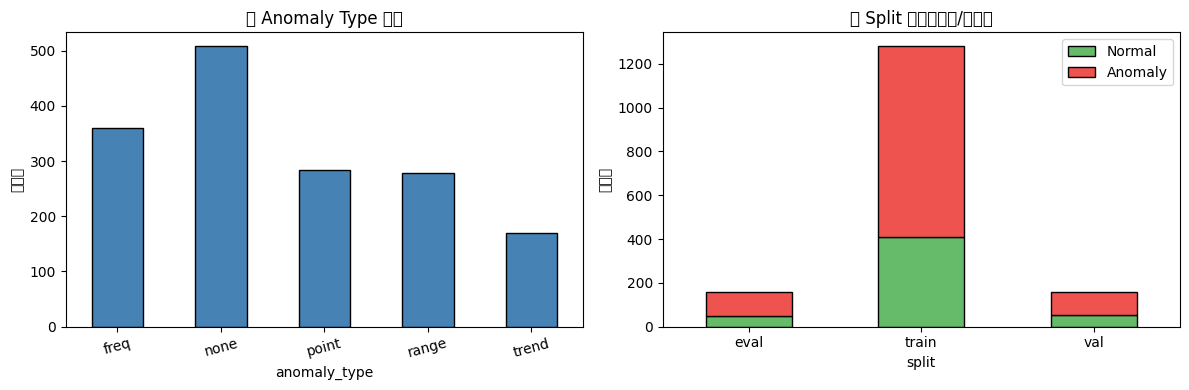

总样本数: 1600  |  train=1280 val=160 eval=160


In [4]:
import pandas as pd, matplotlib.pyplot as plt

manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 左：按 anomaly_type 分布
type_counts = manifest["anomaly_type"].value_counts().sort_index()
type_counts.plot.bar(ax=axes[0], color="steelblue", edgecolor="black")
axes[0].set_title("按 Anomaly Type 分布")
axes[0].set_ylabel("样本数")
axes[0].tick_params(axis="x", rotation=15)

# 右：按 split 分布（stacked by label）
split_label = manifest.groupby(["split", "label"]).size().unstack("label", fill_value=0)
split_label.columns = ["Normal", "Anomaly"]
split_label.plot.bar(ax=axes[1], stacked=True, color=["#66BB6A", "#EF5350"], edgecolor="black")
axes[1].set_title("按 Split 分布（正常/异常）")
axes[1].set_ylabel("样本数")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend()

fig.tight_layout()
plt.show()
print(f"总样本数: {len(manifest)}  |  train={len(manifest[manifest.split=='train'])} "
      f"val={len(manifest[manifest.split=='val'])} eval={len(manifest[manifest.split=='eval'])}")

---
## 阶段 6. 教师蒸馏与清洗

### Cell 6.1 — 设置教师模型

**🔑 需要你操作**：将下方 `sk-xxxx` 替换为你的百炼 API Key，这是整个 notebook 中**唯一需要手动修改**的地方。

In [ ]:
import os
os.environ["DASHSCOPE_API_KEY"] = "sk-xxxx"  # 🔑 替换为你的百炼 API Key

TEACHER_MODEL = "qwen3.5-plus"
TEACHER_TEMPERATURE = 0.2


### Cell 6.2a — 蒸馏冒烟（20 条）

先用 20 条样本验证教师 API 连通性和返回格式。

In [6]:
import base64, json, pandas as pd
from openai import OpenAI

client = OpenAI(
    api_key=os.environ["DASHSCOPE_API_KEY"],
    base_url="https://dashscope.aliyuncs.com/compatible-mode/v1",
)

SYSTEM = "You are annotating time-series anomaly plots for supervised fine-tuning. Return strict JSON only."
VISION_USER_TEXT = ("Detect ranges of anomalies in this time series, "
                    "in terms of the x-axis coordinate.\n"
                    "List one by one, in JSON format.\n"
                    "If there are no anomalies, answer with an empty list [].\n\n"
                    "Output template:\n"
                    '[{\"start\": ..., \"end\": ...}, {\"start\": ..., \"end\": ...}...]')
USER = (f"{VISION_USER_TEXT}\n\n"
        "Return a strict JSON object with keys: "
        "is_anomaly (bool), anomaly_type (point|range|freq|trend|none), "
        "intervals ([{\"start\": int, \"end\": int}, ...] or []), rationale (str). "
        "No markdown.")

def distill_batch(df, out_path):
    with open(out_path, "w") as fout:
        for _, row in df.iterrows():
            with open(row["image_path"], "rb") as f:
                b64 = base64.b64encode(f.read()).decode()
            resp = client.chat.completions.create(
                model=TEACHER_MODEL,
                messages=[
                    {"role": "system", "content": SYSTEM},
                    {"role": "user", "content": [
                        {"type": "text", "text": USER},
                        {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{b64}"}},
                    ]},
                ],
                response_format={"type": "json_object"},
                extra_body={"enable_thinking": False},
                temperature=TEACHER_TEMPERATURE,
            )
            result = json.loads(resp.choices[0].message.content)
            result["sample_id"]      = row["sample_id"]
            result["image_path"]     = row["image_path"]
            result["ground_truth"]   = int(row["label"])
            result["split"]          = row["split"]
            fout.write(json.dumps(result, ensure_ascii=False) + "\n")
    print(f"写入 {out_path}，共 {len(df)} 条")

manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")
sft_df   = manifest[manifest["split"].isin(["train", "val"])]

# ---- 冒烟：只跑 20 条 ----
distill_batch(sft_df.head(20), "/content/tsad_runtime/sft/sft_raw_smoke.jsonl")

写入 /content/tsad_runtime/sft/sft_raw_smoke.jsonl，共 20 条


### 📊 可视化：蒸馏冒烟质量检查

In [ ]:
import json

records = []
with open("/content/tsad_runtime/sft/sft_raw_smoke.jsonl") as f:
    for line in f:
        records.append(json.loads(line))

# 一致性统计
match = sum(1 for r in records if bool(r.get("is_anomaly", False)) == bool(r["ground_truth"]))
total = len(records)

# intervals 格式合法性
def valid_interval(iv):
    return (isinstance(iv, dict)
            and isinstance(iv.get("start"), (int, float))
            and isinstance(iv.get("end"), (int, float))
            and iv["start"] < iv["end"])

fmt_ok = sum(1 for r in records
             if isinstance(r.get("intervals", []), list)
             and all(valid_interval(iv) for iv in r.get("intervals", [])))

print(f"冒烟样本数: {total}")
print(f"is_anomaly 与 ground_truth 一致: {match}/{total} ({match/total:.0%})")
print(f"intervals 格式合法: {fmt_ok}/{total} ({fmt_ok/total:.0%})")

print("\n--- 蒸馏结果 ---")
for r in records[:]:
    print(f"  {r['sample_id']} | gt={r['ground_truth']} teacher={r.get('is_anomaly')} "
          f"intervals={r.get('intervals')}")

if match / total >= 0.7 and fmt_ok / total >= 0.7:
    print("\n✅ 冒烟质量合格，可继续运行全量蒸馏")
else:
    print("\n⚠️ 质量不足，请检查教师 prompt 或 API 返回")

冒烟样本数: 20
is_anomaly 与 ground_truth 一致: 20/20 (100%)
intervals 格式合法: 20/20 (100%)


**⏸ 需要你判断**：检查上方蒸馏冒烟结果。一致率 ≥ 70% 且格式合法率 ≥ 70% 即可继续运行下方全量蒸馏 cell。

> 若质量不足 → 检查 API Key 是否正确、教师模型是否可用。

### Cell 6.2b — 全量蒸馏

对所有 train + val 样本调用教师模型。

In [8]:
# 全量蒸馏（复用上面定义的 distill_batch / client / sft_df）
distill_batch(sft_df, "/content/tsad_runtime/sft/sft_raw.jsonl")

写入 /content/tsad_runtime/sft/sft_raw.jsonl，共 1440 条


In [1]:
from pathlib import Path
import shutil

src = Path("/content/tsad_runtime/sft/sft_raw.jsonl")
dst = Path("/content/drive/MyDrive/tsad_anomaly/sft_raw.jsonl")

assert src.exists(), f"文件不存在: {src}"
dst.parent.mkdir(parents=True, exist_ok=True)

shutil.copy2(src, dst)
print(f"已保存到: {dst}")


已保存到: /content/drive/MyDrive/tsad_anomaly/sft_raw.jsonl


### Cell 6.3 — 自动清洗（label 一致 + intervals 格式合法才保留）

对全量蒸馏结果 `sft_raw.jsonl` 进行清洗。

In [11]:
import json

def valid_interval(interval):
    return (
        isinstance(interval, dict)
        and isinstance(interval.get("start"), (int, float))
        and isinstance(interval.get("end"), (int, float))
        and interval["start"] < interval["end"]
    )

clean, reject = [], []
with open("/content/tsad_runtime/sft/sft_raw.jsonl") as f:
    for line in f:
        r = json.loads(line)
        intervals = r.get("intervals", [])
        teacher_anom = bool(r.get("is_anomaly", False))
        ground_truth = bool(r["ground_truth"])
        intervals_ok = isinstance(intervals, list) and all(valid_interval(iv) for iv in intervals)
        consistent = intervals_ok and (teacher_anom == bool(intervals))
        if teacher_anom == ground_truth and consistent:
            clean.append(r)
        else:
            reject.append(r)

with open("/content/tsad_runtime/sft/sft_final.jsonl", "w") as f:
    for r in clean:
        f.write(json.dumps(r, ensure_ascii=False) + "\n")

print(f"clean={len(clean)}, reject={len(reject)}, "
      f"keep_rate={len(clean)/(len(clean)+len(reject)):.1%}")

clean=1292, reject=148, keep_rate=89.7%


### 📊 可视化：蒸馏清洗统计

/tmp/ipykernel_7979/3580868013.py:37: UserWarning: Glyph 33976 (\N{CJK UNIFIED IDEOGRAPH-84B8}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/3580868013.py:37: UserWarning: Glyph 39311 (\N{CJK UNIFIED IDEOGRAPH-998F}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/3580868013.py:37: UserWarning: Glyph 28165 (\N{CJK UNIFIED IDEOGRAPH-6E05}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/3580868013.py:37: UserWarning: Glyph 27927 (\N{CJK UNIFIED IDEOGRAPH-6D17}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/3580868013.py:37: UserWarning: Glyph 32467 (\N{CJK UNIFIED IDEOGRAPH-7ED3}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/3580868013.py:37: UserWarning: Glyph 26524 (\N{CJK UNIFIED IDEOGRAPH-679C}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipykernel_7979/3580868013.py:37: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}

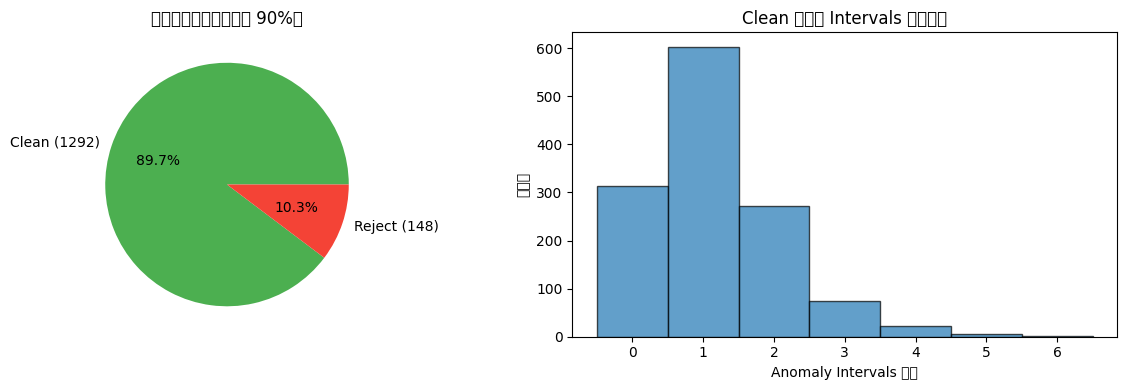

raw=1440, clean=1292, reject=148


In [12]:
import json, matplotlib.pyplot as plt

raw_count = sum(1 for _ in open("/content/tsad_runtime/sft/sft_raw.jsonl"))
clean_count = sum(1 for _ in open("/content/tsad_runtime/sft/sft_final.jsonl"))
reject_count = raw_count - clean_count
keep_rate = clean_count / raw_count if raw_count else 0.0

interval_counts = []
with open("/content/tsad_runtime/sft/sft_final.jsonl") as f:
    for line in f:
        r = json.loads(line)
        interval_counts.append(len(r.get("intervals", [])))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if raw_count > 0:
    axes[0].pie([clean_count, reject_count],
                labels=[f"Clean ({clean_count})", f"Reject ({reject_count})"],
                autopct="%1.1f%%", colors=["#4CAF50", "#F44336"])
    axes[0].set_title(f"蒸馏清洗结果（保留率 {keep_rate:.0%}）")
else:
    axes[0].text(0.5, 0.5, "sft_raw.jsonl 为空", ha="center", va="center")
    axes[0].set_title("蒸馏清洗结果")
    axes[0].axis("off")

if interval_counts:
    axes[1].hist(interval_counts, bins=range(0, max(interval_counts) + 2),
                 edgecolor="black", alpha=0.7, align="left")
    axes[1].set_xlabel("Anomaly Intervals 数量")
    axes[1].set_ylabel("样本数")
    axes[1].set_title("Clean 样本的 Intervals 数量分布")
else:
    axes[1].text(0.5, 0.5, "无 clean 样本", ha="center", va="center")
    axes[1].set_title("Clean 样本的 Intervals 数量分布")
    axes[1].axis("off")

fig.tight_layout()
plt.show()
print(f"raw={raw_count}, clean={clean_count}, reject={reject_count}")

---
## 阶段 7. 转成 Unsloth 训练格式

### Cell 7.1 — 生成 messages 格式 JSONL

In [13]:
import json

USER_TEXT = VISION_USER_TEXT

writers = {
    "train": open("/content/tsad_runtime/sft/train.jsonl", "w"),
    "val":   open("/content/tsad_runtime/sft/val.jsonl",   "w"),
}

with open("/content/tsad_runtime/sft/sft_final.jsonl") as f:
    for line in f:
        r = json.loads(line)
        assistant = json.dumps(r.get("intervals", []), ensure_ascii=False)
        record = {"messages": [
            {"role": "user", "content": [
                {"type": "text",  "text":  USER_TEXT},
                {"type": "image", "image": r["image_path"]},
            ]},
            {"role": "assistant", "content": assistant},
        ]}
        writers[r["split"]].write(json.dumps(record, ensure_ascii=False) + "\n")

for f in writers.values():
    f.close()

### Cell 7.2 — eval split 单独转（导出评估元数据）

In [14]:
import json, pandas as pd

manifest = pd.read_csv("/content/tsad_runtime/sft/sft_manifest.csv")
eval_rows = manifest[manifest["split"] == "eval"]

with open("/content/tsad_runtime/sft/eval.jsonl", "w") as f:
    for _, row in eval_rows.iterrows():
        record = {
            "sample_id":   row["sample_id"],
            "image_path":  row["image_path"],
            "label":       int(row["label"]),
            "anomaly_type": row["anomaly_type"],
            "intervals":   row["intervals"],
        }
        f.write(json.dumps(record, ensure_ascii=False) + "\n")

---
## 切换到 Part 3

### Cell 7.3 — 打包阶段 5-7 产物到 Drive

运行下方 cell 后会在 Drive 生成 `before_stage8_*.tar.gz`。`tsad_sft_pipeline_part3.ipynb` 只需要恢复这个包即可继续训练、导出和评估。

In [15]:
import tarfile, time

SUBSETS = ["flat-trend", "range", "point", "freq"]

ts = time.strftime("%Y%m%d_%H%M%S")
archive_path = DRV_PACK / f"before_stage8_{ts}.tar.gz"
archive_path.parent.mkdir(parents=True, exist_ok=True)

sources = []
required_sft = [
    RT_SFT / "sft_manifest.csv",
    RT_SFT / "sft_raw_smoke.jsonl",
    RT_SFT / "sft_raw.jsonl",
    RT_SFT / "sft_final.jsonl",
    RT_SFT / "train.jsonl",
    RT_SFT / "val.jsonl",
    RT_SFT / "eval.jsonl",
]
missing = [str(path) for path in required_sft if not path.exists()]
if missing:
    raise FileNotFoundError("缺少阶段 5-7 产物:\n" + "\n".join(missing))

for path in required_sft:
    sources.append((path, path.relative_to(RUNTIME)))

baseline_path = RT_RESULTS / "baseline_compare.csv"
if not baseline_path.exists():
    raise FileNotFoundError(f"缺少 baseline_compare.csv: {baseline_path}")
sources.append((baseline_path, baseline_path.relative_to(RUNTIME)))

for subset in SUBSETS:
    data_pkl = ANOMLLM / "data" / "synthetic" / subset / "eval" / "data.pkl"
    qwen_jsonl = ANOMLLM / "results" / "synthetic" / subset / "qwen-local" / "0shot-vision.jsonl"
    iso_jsonl = ANOMLLM / "results" / "synthetic" / subset / "isolation-forest" / "0shot.jsonl"
    agg_pkl = ANOMLLM / "results" / "agg" / f"{subset}.pkl"
    required = [data_pkl, qwen_jsonl, iso_jsonl, agg_pkl]
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError("缺少 Part 3 评估所需文件:\n" + "\n".join(missing))
    for path in required:
        sources.append((path, path.relative_to(RUNTIME)))

    figs_dir = data_pkl.parent / "figs"
    if not figs_dir.exists():
        raise FileNotFoundError(f"缺少 figs 目录: {figs_dir}")
    for fig in figs_dir.rglob("*.png"):
        sources.append((fig, fig.relative_to(RUNTIME)))

with tarfile.open(archive_path, "w:gz") as tar:
    for abs_path, arc_name in sources:
        tar.add(abs_path, arcname=str(arc_name))

print(f"✅ 已打包 {len(sources)} 个文件 → {archive_path}")


✅ 已打包 1624 个文件 → /content/drive/MyDrive/tsad_anomaly/packs/before_stage8_20260404_224304.tar.gz
